# 1 Data Ingestion

In [152]:
import pandas as pd

df = pd.read_csv('../dataset/creditcard.csv')

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [153]:
# Cek missing
print(df.isnull().sum())

# Cek duplikasi
print(df.duplicated().sum())
# Remove duplikasi data jika ada
df = df.drop_duplicates()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
1081


# 2. Exploratory Data Analysis (EDA)

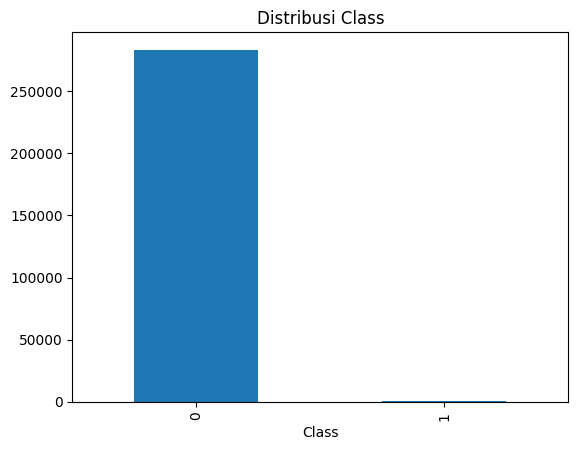

In [154]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Distribusi Class")
plt.show()

# 3. Advanced Preprocessing

In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)

# 4. Scientific Balancing 

In [156]:
# Subset + SMOTE
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# ambil subset (biar cepat)
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=20000, stratify=y, random_state=42
)


from imblearn.over_sampling import SMOTE

# Jumlah SMOTE data minoritas adalah 30% dari data minoritas
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_res, y_res = smote.fit_resample(X_small, y_small)

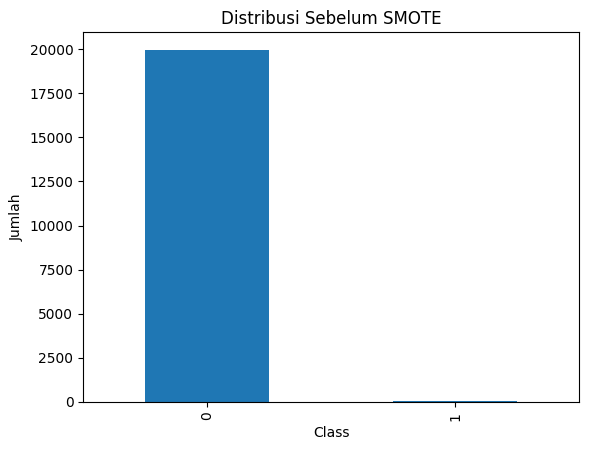

In [157]:
import matplotlib.pyplot as plt
import pandas as pd


# sebelum SMOTE
plt.figure()
pd.Series(y_small).value_counts().plot(kind='bar')
plt.title("Distribusi Sebelum SMOTE")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()


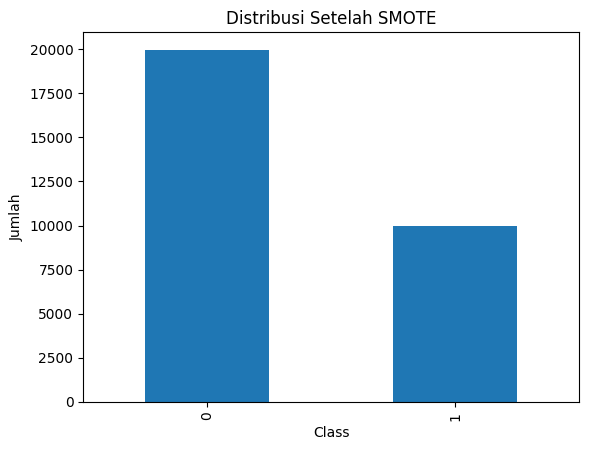

In [158]:
# sesudah SMOTE
plt.figure()
pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("Distribusi Setelah SMOTE")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

# 5. Data Partitioning

In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=42
)

# Studi kasus mahasiswa 2 - Model Analyst & Strategyt

## 1. Architecture Design

In [160]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced', max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

## 2. Performance Audit

In [161]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3884  109]
 [  16 1981]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3993
           1       0.95      0.99      0.97      1997

    accuracy                           0.98      5990
   macro avg       0.97      0.98      0.98      5990
weighted avg       0.98      0.98      0.98      5990



## 3. Explainable AI (XAI)

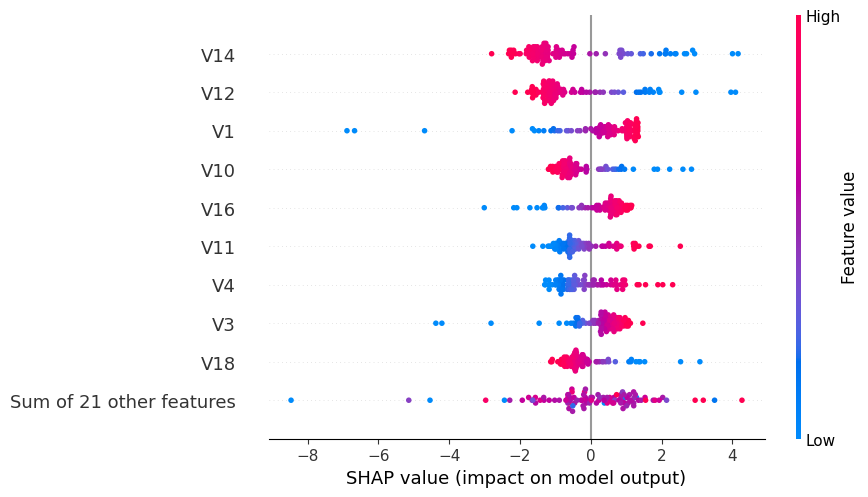

In [162]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test[:100])

shap.plots.beeswarm(shap_values)

## 4. Policy Simulation (What-if)

In [163]:
sample = X_test.iloc[0].copy()

# Prediksi awal
pred_awal = model.predict([sample])[0]

# ubah amount (simulasi transaksi besar)
sample['scaled_amount'] *= 100

# Prediksi setelah perubahan
pred_baru = model.predict([sample])[0]

pred = model.predict([sample])
print("Sebelum: ", pred_awal)
print("Sesudah: ", pred_baru)


Sebelum:  0
Sesudah:  1


/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
